In [289]:
import pandas as pd
import numpy as np
import mysql.connector as sql
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from IPython.display import display, Markdown

In [290]:
sns.set_theme(style="whitegrid")

In [291]:
db = sql.connect(
    host="giniewicz.it",
    user="team07",
    password="te@mlot",
    database="team07",
    port=3306,
)

db.is_connected()

True

In [292]:
cursor = db.cursor()



Połącz bazę danych z wybranym narzędziem (może być inne niż w poprzedniej części!).
1. Znajdź najpopularniejsze rodzaje wypraw, porównaj koszta i zyski, czy są opłacalne?
2. Sporządź wykres liczby obsłużonych klientów w każdym miesiącu działalności firmy, czy firma rośnie, czy podupada?
3. Sprawdź, po których wycieczkach klienci wracają na kolejne, a po których mają dość i więcej ich nie widzicie. Czy są takie, które być może powinny zniknąć z oferty?
4. Postaw i odpowiedz analizą na minimum cztery dodatkowe pytania.



# Znajdź najpopularniejsze rodzaje wypraw, porównaj koszta i zyski, czy są opłacalne?

Wybierzmy 5 najpopularniejszych wypraw.

In [293]:
top_5_trips_query = """
SELECT name, COUNT(*) as trip_count
FROM Trips
GROUP BY name
ORDER BY COUNT(*) DESC
LIMIT 5
"""
cursor.execute(top_5_trips_query)
trips = cursor.fetchall()
top_5_trips_df = pd.DataFrame(trips, columns=[i[0] for i in cursor.description])

In [294]:
top_5_trips_kind_customers_df = pd.DataFrame()
top_5_trips_kind_details_df = pd.DataFrame()

for name in top_5_trips_df['name'].values:
    named_trips_query = f"""
    SELECT trip_id, organization_cost, launch_date, name
    FROM Trips
    WHERE name = '{name}'
    """
    cursor.execute(named_trips_query)
    trip_data = cursor.fetchall()

    top_5_trips_kind_details_df = pd.concat([top_5_trips_kind_details_df, pd.DataFrame(trip_data, columns=[i[0] for i in cursor.description])])

    for trip_id, *_ in trip_data:

        trip_query = f"""
        SELECT participant_id, pesel, trip_id, ticket_price
        FROM TripParticipants 
        WHERE trip_id = {trip_id}
        """
        cursor.execute(trip_query)
        participants = cursor.fetchall()
        top_5_trips_kind_customers_df = pd.concat([top_5_trips_kind_customers_df, pd.DataFrame(participants, columns=[i[0] for i in cursor.description])])

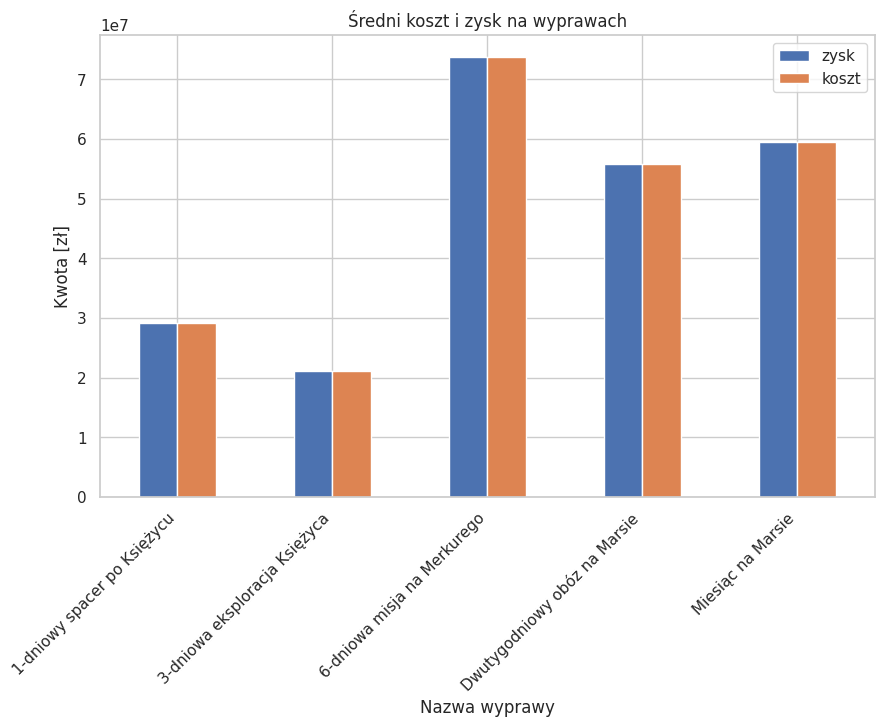

In [295]:
zyski_koszta =  top_5_trips_kind_customers_df.join(
    top_5_trips_kind_details_df.set_index('trip_id'),
    on='trip_id',
    lsuffix='_customer',
    rsuffix='_details'
).groupby('trip_id').agg(
    _payout =('ticket_price', 'sum'),
    _cost = ('organization_cost', 'first'),
    name = ('name', 'first'),
).groupby('name').agg(
    zysk = ('_payout', 'mean'),
    koszt = ('_cost', 'mean'),
)

ax = zyski_koszta.plot.bar(
    y=['zysk', 'koszt'],
    title='Średni koszt i zysk na wyprawach',
    ylabel='Kwota [zł]',
    xlabel='Nazwa wyprawy',
    figsize=(10, 6),
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

Widzimy, że koszt i zysk wypraw jest praktycznie ten sam.

Text(0.5, 0, '')

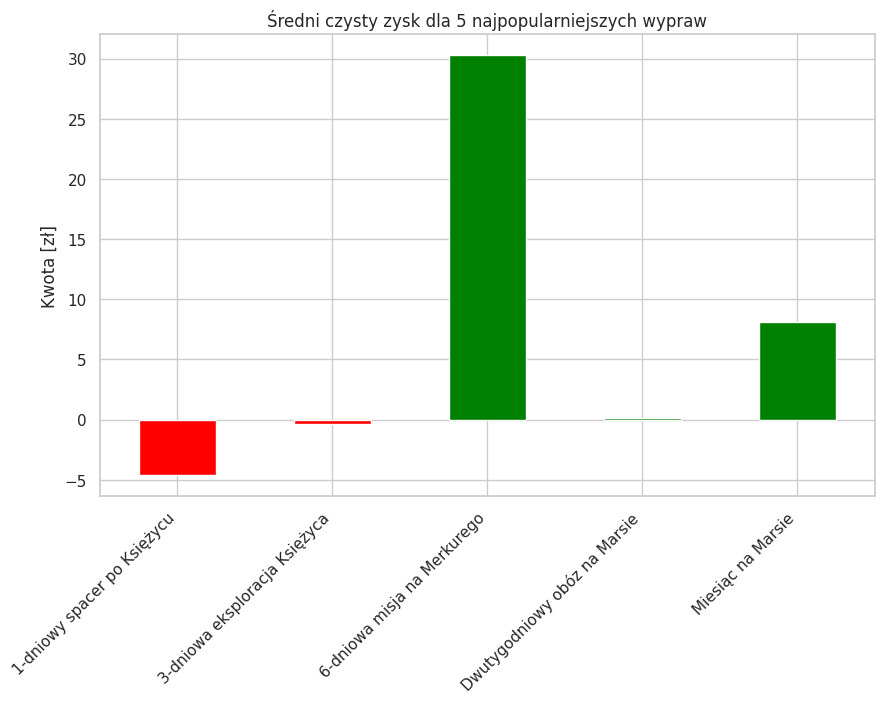

In [296]:
zyski_koszta['czysty_zysk'] = zyski_koszta['zysk'] - zyski_koszta['koszt']
colors = ['red' if x < 0 else 'green' for x in zyski_koszta['czysty_zysk']]
ax = zyski_koszta['czysty_zysk'].plot.bar(
    title='Średni czysty zysk dla 5 najpopularniejszych wypraw',
    ylabel='Kwota [zł]',

    figsize=(10, 6),
    color=colors
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');
ax.set_xlabel(None)

Czysty zysk jest naprawdę marginalny w porównaniu z kosztami wyprawy dla 5 najpopularniejszych wypraw. Jak wygląda to w kontekście wszystkich wypraw?

In [297]:
payout_from_all_query = """
SELECT
    SUM(ticket_price) AS total_payout, Trips.trip_id, name, organization_cost
FROM
    TripParticipants
JOIN Trips ON TripParticipants.trip_id = Trips.trip_id
GROUP BY
    Trips.trip_id
"""

cursor.execute(payout_from_all_query)
payout_from_all = cursor.fetchall()
payout_from_all_df = pd.DataFrame(payout_from_all, columns=[i[0] for i in cursor.description])

In [298]:
payout_from_all_df['czysty_zysk'] = payout_from_all_df['total_payout'] - payout_from_all_df['organization_cost'].astype(float)

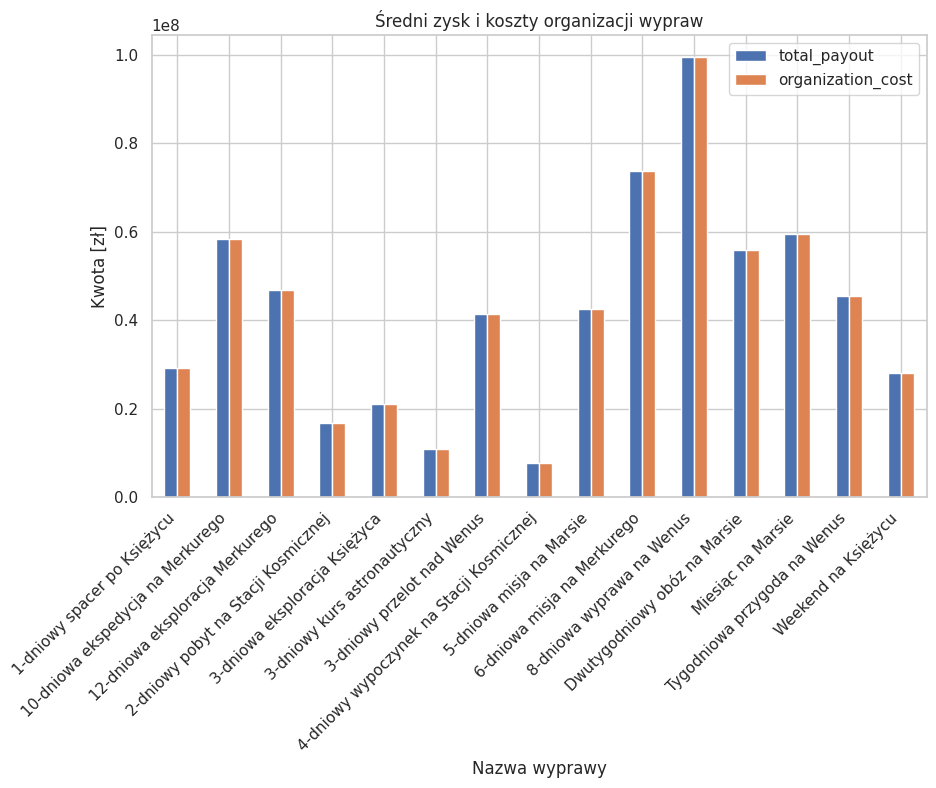

In [299]:
payout_from_all_df.groupby('name').agg(
    czysty_zysk=('czysty_zysk', 'mean'),
    total_payout=('total_payout', 'mean'),
    organization_cost=('organization_cost', 'mean'),
).plot.bar(
    y=['total_payout', 'organization_cost'],
    title='Średni zysk i koszty organizacji wypraw',
    ylabel='Kwota [zł]',
    xlabel='Nazwa wyprawy',
    figsize=(10, 6),
)
plt.xticks(rotation=45, ha='right');

Brak znaczącego zysku nie ogranicza się tylko do wcześniej wymienionych wypraw ale do **wszystkich**. Wygląda na to, że firma nie ma planów na jakiekolwiek inwestycje i w związku z tym nie podności marży. W takim razie sprawdźmy czy taka strategia powoduje stratę klientów.

launch_date
2168-08-25    15.000000
2168-12-29    14.500000
2169-01-05    14.833333
2169-01-12    14.833333
2169-01-19    14.833333
                ...    
2186-01-12    15.066667
2186-01-19    15.066667
2186-01-26    15.166667
2186-02-02    15.166667
2186-02-09    14.533333
Name: participants_count, Length: 340, dtype: float64


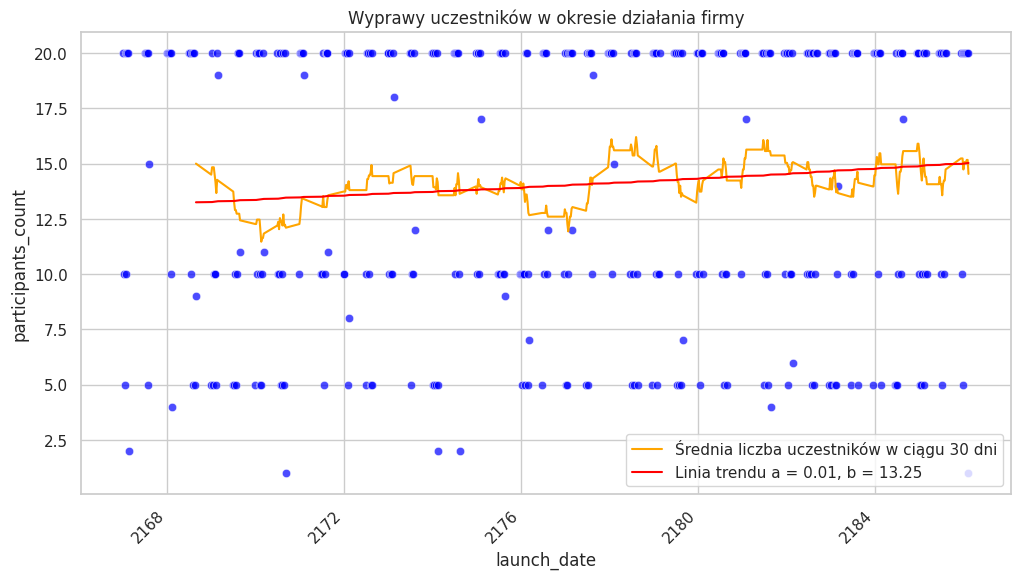

In [300]:
participants_query = """
SELECT
    COUNT(*) AS participants_count,
    launch_date
FROM
    TripParticipants
JOIN Trips ON TripParticipants.trip_id = Trips.trip_id
GROUP BY
    launch_date
ORDER BY
    launch_date
"""

cursor.execute(participants_query)
participants = cursor.fetchall()
participants_df = pd.DataFrame(participants, columns=[i[0] for i in cursor.description])
participants_df['launch_date'] = pd.to_datetime(participants_df['launch_date'])
participants_df.set_index('launch_date', inplace=True)


plt.figure(figsize=(12, 6))


sns.scatterplot(
    data=participants_df,
    x=participants_df.index,
    y='participants_count',
    color='blue',
    alpha=0.7
)
plt.xticks(rotation=45, ha='right');

thirty_days_mean = participants_df['participants_count'].rolling(window=30).mean().dropna()

sns.lineplot(
    data=thirty_days_mean,
    color='orange',
    label='Średnia liczba uczestników w ciągu 30 dni'
)

plt.title('Wyprawy uczestników w okresie działania firmy')
plt.xticks(rotation=45, ha='right');

print(thirty_days_mean)
a, b = stats.linregress(
    np.arange(len(thirty_days_mean)),
    thirty_days_mean
)[:2]

trendline = a * np.arange(len(thirty_days_mean)) + b
plt.plot(
    thirty_days_mean.index,
    trendline,
    color='red',
    label=f'Linia trendu a = {a:.2f}, b = {b:.2f}'
)
plt.legend()

Liczba uczestników wypraw wacha się często pomiędzy 20, 10 i 5. Nie ma widocznych anomalii, dane są bardzo regularne. Współczynik kierunowy uzyskany przez regresje liniową $a = 0.01$ wskazuję na mały wzrost zainteresowanią firmą w ciągu lat. Czyli firma nie traci klientów, a nawet ich zyskuje! W takim wypadku pozostaje tylko zbadać które wyprawy ponownie przyciągają klientów.

# (Część Nadii)

Teraz spójrzmy na rozkład zarobków w firmie w zależności od roli.

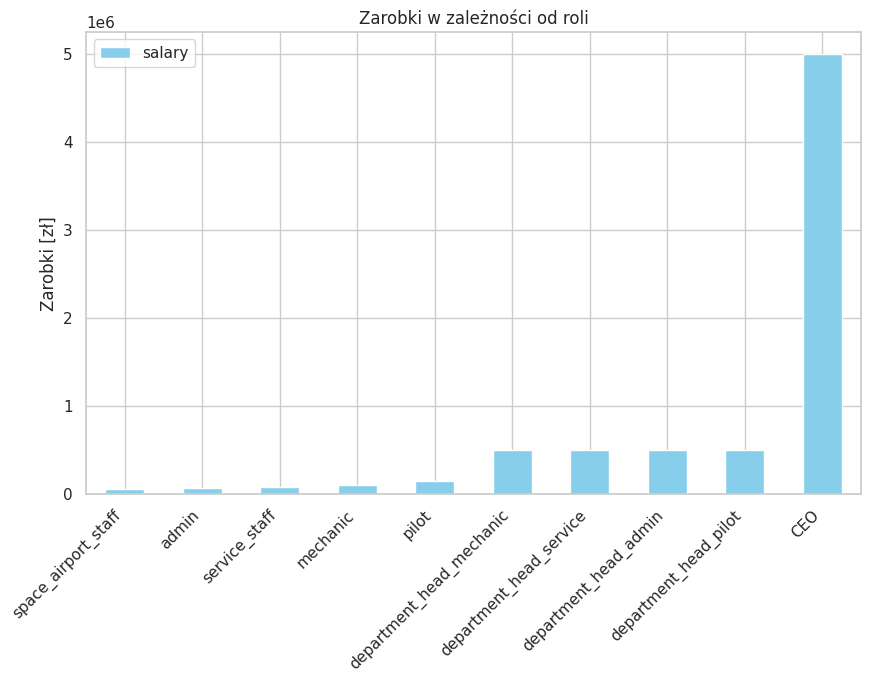

In [301]:
employees_query = """SELECT
    role,
    salary,
    STDDEV(salary) AS salary_std
FROM
    Employees
GROUP BY
    role
ORDER BY
    role
"""
cursor.execute(employees_query)
employees = cursor.fetchall()
employees_df = pd.DataFrame(employees, columns=[i[0] for i in cursor.description]) 



employees_df['salary'] = employees_df['salary'].astype(float)

employees_df.sort_values(by='salary').plot(
    kind='bar',
    y='salary',
    x='role',
    title='Zarobki w zależności od roli',
    ylabel='Zarobki [zł]',
    figsize=(10, 6),
    xlabel='Rola',
    color='skyblue'
)

plt.xticks(rotation=45, ha='right');
plt.xlabel(None)

employees_salary_mean = employees_df['salary'].mean()
employees_salary_std = employees_df['salary'].std()

no_ceo_employees_salary_mean = employees_df[employees_df['role'] != 'CEO']['salary'].mean()
no_ceo_employees_salary_std = employees_df[employees_df['role'] != 'CEO']['salary'].std()

In [302]:
display(Markdown(f"""## Średnia i odchylenie standardowe zarobków
Średnie zarobki w firmie wynoszą **{employees_salary_mean:.2f} zł**, a odchylenie standardowe to **{employees_salary_std:.2f} zł**.
Natomiast bez uwzględnienia CEO średnia zarobków wynosi **{no_ceo_employees_salary_mean:.2f} zł**, a odchylenie standardowe to **{no_ceo_employees_salary_std:.2f} zł**.
Najmniej zarabiają pracownicy portu kosmicznego bo tylko **{employees_df[employees_df['role'] == 'space_airport_staff']['salary'].values[0]:.2f} zł**,
a najwięcej CEO, który zarabia **{employees_df[employees_df['role'] == 'CEO']['salary'].values[0]:.2f} zł**. Jest to różnica dwóch rzędów wielkości. Przyjrzyjmy się teraz wydajności pracowników. Który wypada najlepiej na tle pozostałych?
"""))

## Średnia i odchylenie standardowe zarobków
Średnie zarobki w firmie wynoszą **745000.00 zł**, a odchylenie standardowe to **1509085.45 zł**.
Natomiast bez uwzględnienia CEO średnia zarobków wynosi **272222.22 zł**, a odchylenie standardowe to **217760.06 zł**.
Najmniej zarabiają pracownicy portu kosmicznego bo tylko **50000.00 zł**,
a najwięcej CEO, który zarabia **5000000.00 zł**. Jest to różnica dwóch rzędów wielkości. Przyjrzyjmy się teraz wydajności pracowników. Który wypada najlepiej na tle pozostałych?


In [303]:
employees_performance_query = """
SELECT
    CONCAT(Employees.first_name, ' ', Employees.last_name) AS full_name,
    Employees.pesel,
    Employees.role,
    specialization,
    COUNT(RecoveryTasks.pesel) + COUNT(RepairTasks.pesel) + COUNT(TripCrew.pesel) as ilosc_zadan
FROM 
    Employees
LEFT JOIN
    RecoveryTasks ON Employees.pesel = RecoveryTasks.pesel
LEFT JOIN
    RepairTasks ON Employees.pesel = RepairTasks.pesel
LEFT JOIN
    TripCrew ON Employees.pesel = TripCrew.pesel
GROUP BY
    Employees.pesel
"""

cursor.execute(employees_performance_query)
employees_performance = cursor.fetchall()
employees_performance_df = pd.DataFrame(employees_performance, columns=[i[0] for i in cursor.description])

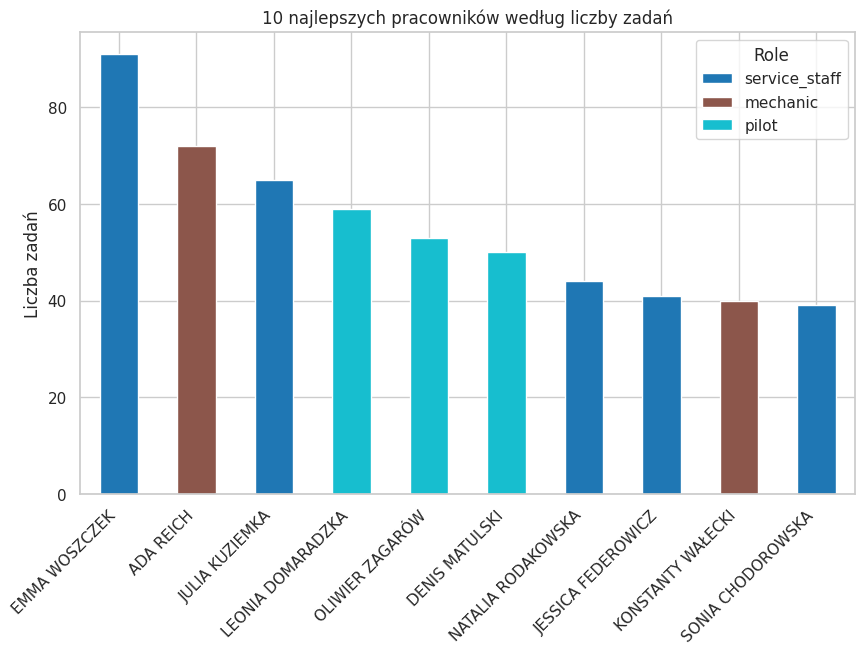

In [304]:
top_10_data = employees_performance_df.sort_values(by='ilosc_zadan', ascending=False).iloc[:10]


unique_roles = top_10_data['role'].unique()
colors = plt.get_cmap('tab10', len(unique_roles))
role_color_map = {role: colors(i) for i, role in enumerate(unique_roles)}

bar_colors = top_10_data['role'].map(role_color_map)

ax = top_10_data.plot(
    kind='bar',
    x='full_name',
    y='ilosc_zadan',
    title='10 najlepszych pracowników według liczby zadań',
    ylabel='Liczba zadań',
    xlabel='PESEL',
    figsize=(10, 6),
    color=bar_colors,
    legend=False
)


from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=role_color_map[role], label=role) for role in unique_roles]
ax.legend(handles=legend_elements, title='Role')

plt.xticks(rotation=45, ha='right');
plt.xlabel(None);

Zadania możemy podzielić na naprawę statku kosmicznego, odzyskiwanie rakiety oraz prowadzenie statku kosmicznego.

Z wykresu mozemy wyczytać, że najwięcej zadań, bo ponad 80, w swojej karierze wykonała Emma Woszczek będąc przy okazji na stanowisku personelu obsługi. Zaraz po niej znajduje się Ada Reich na stanowisku mechanika. Natomiast pierwszym pilotem w rankingu jest Leonia Domaradzka. Spójrzmy teraz na te 3 grupy. Która z nich średnio wykonała najwięcej zadań?

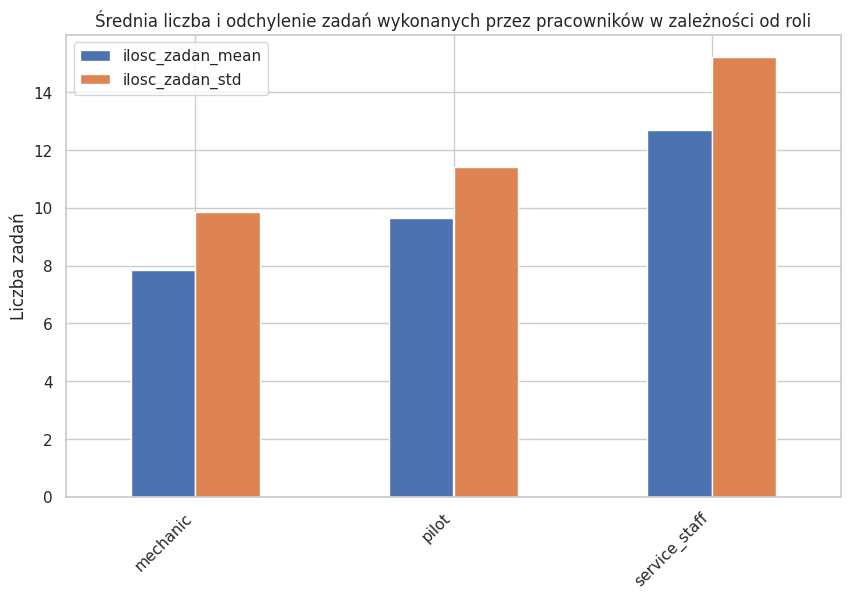

In [305]:
employees_performance_df.where(
    lambda x: x['ilosc_zadan'] > 0).groupby('role').agg(
    ilosc_zadan_mean=('ilosc_zadan', 'mean'),
    ilosc_zadan_std=('ilosc_zadan', 'std')
).plot.bar(
    y=['ilosc_zadan_mean', 'ilosc_zadan_std'],
    title='Średnia liczba i odchylenie zadań wykonanych przez pracowników w zależności od roli',
    ylabel='Liczba zadań',
    xlabel='Rola',
    figsize=(10, 6),
)
plt.xticks(rotation=45, ha='right');
plt.xlabel(None);

Jak możemy zauważyć, średnio najwięcej zadań przymuje personel obsługi, mając jednocześnie największe odchylenie. Warto też wspomnieć, że zarobki personelu obłsugi są najmniejsze z tej trójki. Przejdźmy teraz do statków kosmicznych. Jaki statek był najdłużej wykorzystywany? Jaki statek ma największy stosunek wylotów do napraw? 

In [306]:
ship_query = """
SELECT
    spaceship_id,
    name,
    type,
    manufacturing_date,
    status
FROM
    Spaceships
"""

repair_query = """
SELECT
    spaceship_id,
    COUNT(*) AS repair_count
FROM
    RepairTasks
GROUP BY
    spaceship_id
"""

cruise_query = """
SELECT
    spaceship_id,
    COUNT(*) AS cruise_count
FROM
    Trips
GROUP BY
    spaceship_id
"""

cursor.execute(ship_query)
ships = cursor.fetchall()
ships_df = pd.DataFrame(ships, columns=[i[0] for i in cursor.description])  

ships_df['manufacturing_date'] = pd.to_datetime(ships_df['manufacturing_date'])


cursor.execute(repair_query)
repairs = cursor.fetchall()
repairs_df = pd.DataFrame(repairs, columns=[i[0] for i in cursor.description])  


cursor.execute(cruise_query)
cruises = cursor.fetchall()
cruises_df = pd.DataFrame(cruises, columns=[i[0] for i in cursor.description])  

ships_repairs_df = ships_df.merge(
    repairs_df,
    on='spaceship_id',
    how='left'
).fillna({'repair_count': 0})

ships_cruises_df = ships_repairs_df.merge(
    cruises_df,
    on='spaceship_id',
    how='left'
).fillna({'cruise_count': 0})   

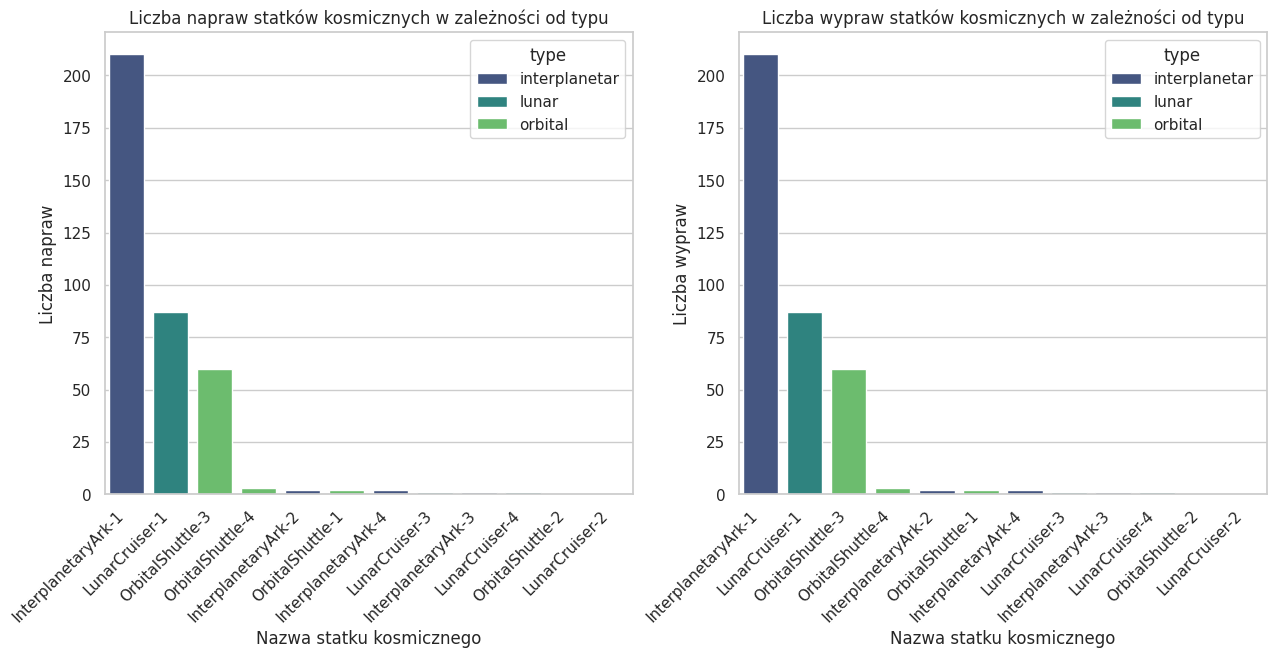

In [307]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)

sns.barplot(
    data=ships_repairs_df.sort_values(by='repair_count', ascending=False),
    x='name',
    y='repair_count',
    hue='type',
    palette='viridis'
)
plt.title('Liczba napraw statków kosmicznych w zależności od typu')
plt.ylabel('Liczba napraw')
plt.xlabel('Nazwa statku kosmicznego')
plt.xticks(rotation=45, ha='right');

plt.subplot(1, 2, 2)
sns.barplot(
    data=ships_cruises_df.sort_values(by='cruise_count', ascending=False),
    x='name',
    y='cruise_count',
    hue='type',
    palette='viridis'
)
plt.title('Liczba wypraw statków kosmicznych w zależności od typu')
plt.ylabel('Liczba wypraw')
plt.xlabel('Nazwa statku kosmicznego')
plt.xticks(rotation=45, ha='right');    

Najczęściej używanymi statkami ze swojej kategorii są *InterplanetaryArk-1*, *LunarCrusier-1* oraz *OrbitalShuttle-3*.


Wykresy ilości napraw statków i ilości wycieczek z ich użyciem są identyczne. Oznacza to, że po każdym zakończonym locie przeprowadzono naprawy statku. Nie ma więc statku który po przelocie byłby całkowicie sprawny, lub po prostu pojęcia naprawy i konserwacji statku jest dla firmy równoważne.